In [2]:
# Part 3.2 — DAWNBench Challenge
# CIFAR-10 + ResNet-18

import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

# Select the best available device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Computation device:", device)

PyTorch version: 2.8.0
CUDA available: False
MPS available: True
Computation device: mps


In [3]:
# Load CIFAR-10 and prepare the data

# CIFAR-10 normalization values
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

# Training transformations
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Testing transformations
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Download/load CIFAR-10
train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Number of classes:", len(train_dataset.classes))
print("Image shape:", train_dataset[0][0].shape)
print("Classes:", train_dataset.classes)

Training images: 50000
Testing images: 10000
Number of classes: 10
Image shape: torch.Size([3, 32, 32])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


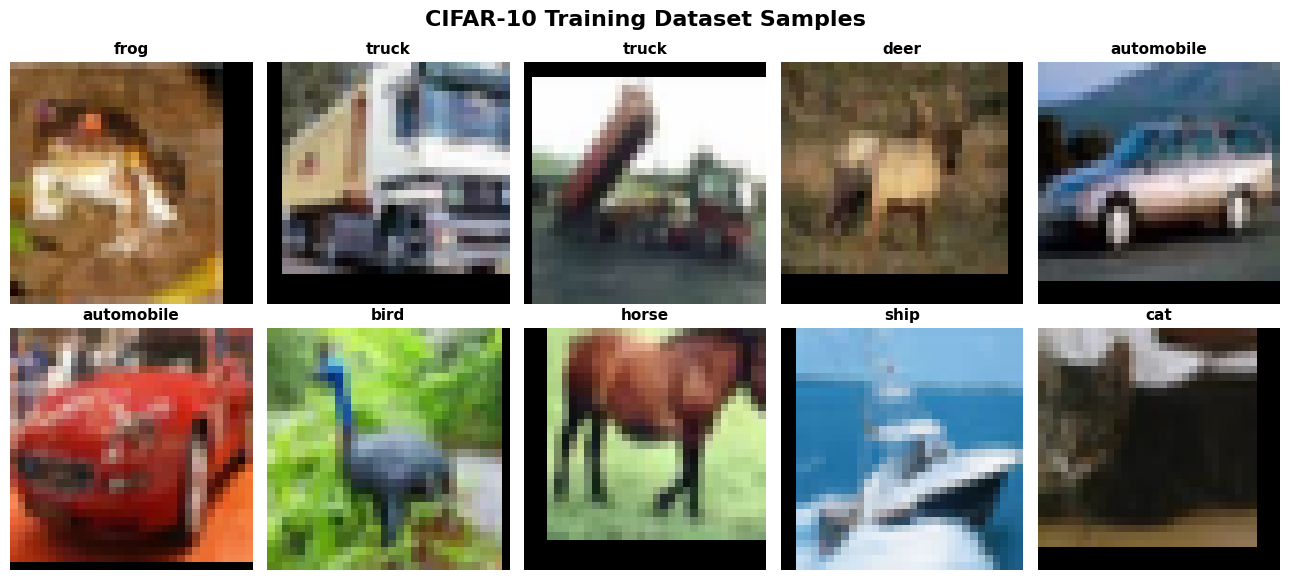

In [4]:
# Visualise a sample of the CIFAR-10 training images

# CIFAR-10 class names
classes = train_dataset.classes

# Create a grid of sample images
fig, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, index in zip(axes.flat, range(10)):
    image, label = train_dataset[index]

    # Undo normalization for display
    image = image.permute(1, 2, 0).numpy()
    image = image * np.array(std) + np.array(mean)
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(classes[label], fontsize=11, fontweight="bold")
    ax.axis("off")

fig.suptitle(
    "CIFAR-10 Training Dataset Samples",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [5]:
# ResNet-18 residual block

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut connection
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out


print("BasicBlock created successfully.")

BasicBlock created successfully.


In [6]:
# ResNet-18 for CIFAR-10

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # Initial convolution
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # ResNet-18 stages: 2 blocks in each stage
        self.layer1 = self._make_layer(
            64, 2, stride=1
        )

        self.layer2 = self._make_layer(
            128, 2, stride=2
        )

        self.layer3 = self._make_layer(
            256, 2, stride=2
        )

        self.layer4 = self._make_layer(
            512, 2, stride=2
        )

        # Global average pooling
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Final classification layer
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []

        # First block may reduce spatial dimensions
        layers.append(
            BasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        # Remaining blocks keep the same dimensions
        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    out_channels,
                    out_channels
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x


# Create the model
model = ResNet18(num_classes=10)

print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)

In [7]:
# Check the ResNet-18 model

# Move model to the selected device
model = model.to(device)

# Count trainable parameters
total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Computation device:", device)
print(f"Trainable parameters: {total_parameters:,}")

# Test a single batch
images, labels = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)

# Verify the output has 10 class scores
assert outputs.shape[1] == 10

print("Model forward pass: SUCCESS")
print("Output classes:", outputs.shape[1])

Computation device: mps
Trainable parameters: 11,173,962


/Users/amardeepsandhu/Desktop/COMP3710/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Input batch shape: torch.Size([128, 3, 32, 32])
Output batch shape: torch.Size([128, 10])
Model forward pass: SUCCESS
Output classes: 10


In [8]:
# Training configuration

num_epochs = 5

# Cross-entropy loss
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)

# SGD optimizer
optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# Cosine learning-rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)

# Mixed precision will be enabled automatically on CUDA
use_amp = device.type == "cuda"

print("Training configuration")
print("-" * 40)
print("Epochs:", num_epochs)
print("Optimizer: SGD")
print("Learning rate:", 0.1)
print("Momentum:", 0.9)
print("Weight decay:", 5e-4)
print("Loss: CrossEntropyLoss")
print("Label smoothing:", 0.1)
print("Learning-rate schedule: Cosine Annealing")
print("Mixed precision:", use_amp)

Training configuration
----------------------------------------
Epochs: 5
Optimizer: SGD
Learning rate: 0.1
Momentum: 0.9
Weight decay: 0.0005
Loss: CrossEntropyLoss
Label smoothing: 0.1
Learning-rate schedule: Cosine Annealing
Mixed precision: False


In [9]:
# Train ResNet-18

train_losses = []
train_accuracies = []
epoch_times = []

print("Starting ResNet-18 training...")
print("=" * 60)

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision on CUDA, normal precision elsewhere
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    epoch_time = time.perf_counter() - epoch_start

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy * 100)
    epoch_times.append(epoch_time)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:3d}/{num_epochs} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy * 100:.2f}% | "
        f"LR: {current_lr:.5f} | "
        f"Time: {epoch_time:.1f}s"
    )

print("=" * 60)
print("Training complete!")
print(f"Total training time: {sum(epoch_times):.1f}s")

Starting ResNet-18 training...
Epoch   1/5 | Loss: 2.1530 | Accuracy: 27.32% | LR: 0.09045 | Time: 305.8s
Epoch   2/5 | Loss: 1.6955 | Accuracy: 43.74% | LR: 0.06545 | Time: 260.0s
Epoch   3/5 | Loss: 1.4932 | Accuracy: 54.28% | LR: 0.03455 | Time: 261.8s
Epoch   4/5 | Loss: 1.3245 | Accuracy: 62.64% | LR: 0.00955 | Time: 259.6s
Epoch   5/5 | Loss: 1.1976 | Accuracy: 68.81% | LR: 0.00000 | Time: 261.1s
Training complete!
Total training time: 1348.3s


In [ ]:
# Evaluate ResNet-18 on the test set

model.eval()

test_correct = 0
test_total = 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct: {test_correct}/{test_total}")

Test Accuracy: 70.08%
Correct: 7008/10000
